In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

import cv2

import numpy as np 

import torch
import torch.nn as nn
import torch.nn.functional as F

from box import Box
import yaml

import matplotlib.pyplot as plt

from scipy.spatial.transform import Rotation as R
import random 

import time 

root_dir = os.path.abspath('../..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

# from src.models.dpso_inference import DPSO

from src.data_loader.evaluation_data_generator import DataGenerator
from src.models.patchifier import Patchifier
# from training.utils import pose_err


In [14]:
model_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/model.yaml'
sonar_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/sonar.yaml'

data_root_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/data/test/aracati'
data_output_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/training/test_output'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(model_config_pth, "r") as f:
            model_config = Box(yaml.safe_load(f))

with open(sonar_config_pth, "r") as f:
            sonar_config = Box(yaml.safe_load(f))

# init_frames = model_config.TIME_WINDOW

from src.data_loader.transforms import SonarDatasetTranforms
data_generator = DataGenerator(data_root_dir, device, transforms = SonarDatasetTranforms)

from src.data_loader.utils import img_polar2cart

data_lenght = data_generator.get_len()
print(f'Data generator initialized.')
print(f'Data series lenght: {data_lenght}')

patchifier = Patchifier(model_config)

Data generator initialized.
Data series lenght: 28


In [4]:
# --- harris ---

limit_frames = 30
r_min = sonar_config.range.min
r_max = sonar_config.range.max
theta_max = sonar_config.fov.horizontal

wait_time_ms = 50 

window_name = 'Sonar Tracking'
cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
cv2.resizeWindow(window_name, 800, 400)

with torch.no_grad():
    for frame_idx in range(limit_frames):

        t, frame, pose, frame_np = data_generator.get_sample(frame_idx, return_visu=True)
        
        coords, patches_f, patches_c, fmap = patchifier(frame, mode='harris')

        frame_np_visu, harris_response = patchifier.get_visu(frame, coords)
        
        frame_keypoints = img_polar2cart(frame_np_visu, r_min, r_max, theta_max, out_shape=None, bg=0)


        cv2.imshow(window_name, frame_keypoints)
        

        key = cv2.waitKey(wait_time_ms) & 0xFF
        if key == ord('q'):
            break

cv2.destroyAllWindows()

In [5]:
# --- DoG ---

limit_frames = 30 
r_min = sonar_config.range.min
r_max = sonar_config.range.max
theta_max = sonar_config.fov.horizontal

wait_time_ms = 50

window_name = 'Sonar Tracking'
cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
cv2.resizeWindow(window_name, 800, 400)

with torch.no_grad():
    for frame_idx in range(limit_frames):

        t, frame, pose, frame_np = data_generator.get_sample(frame_idx, return_visu=True)
        
        coords, patches_f, patches_c, fmap = patchifier(frame, mode='DoG')

        frame_np_visu, harris_response = patchifier.get_visu(frame, coords)
        
        frame_keypoints = img_polar2cart(frame_np_visu, r_min, r_max, theta_max, out_shape=None, bg=0)


        cv2.imshow(window_name, frame_keypoints)
        

        key = cv2.waitKey(wait_time_ms) & 0xFF
        if key == ord('q'):
            break

cv2.destroyAllWindows()

In [6]:
# --- hessian ---

limit_frames = 30 
r_min = sonar_config.range.min
r_max = sonar_config.range.max
theta_max = sonar_config.fov.horizontal

wait_time_ms = 50

window_name = 'Sonar Tracking'
cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
cv2.resizeWindow(window_name, 800, 400)

with torch.no_grad():
    for frame_idx in range(limit_frames):

        t, frame, pose, frame_np = data_generator.get_sample(frame_idx, return_visu=True)
        
        coords, patches_f, patches_c, fmap = patchifier(frame, mode='hessian')

        frame_np_visu, harris_response = patchifier.get_visu(frame, coords)
        
        frame_keypoints = img_polar2cart(frame_np_visu, r_min, r_max, theta_max, out_shape=None, bg=0)


        cv2.imshow(window_name, frame_keypoints)
        

        key = cv2.waitKey(wait_time_ms) & 0xFF
        if key == ord('q'):
            break

cv2.destroyAllWindows()

NameError: name 'kf' is not defined

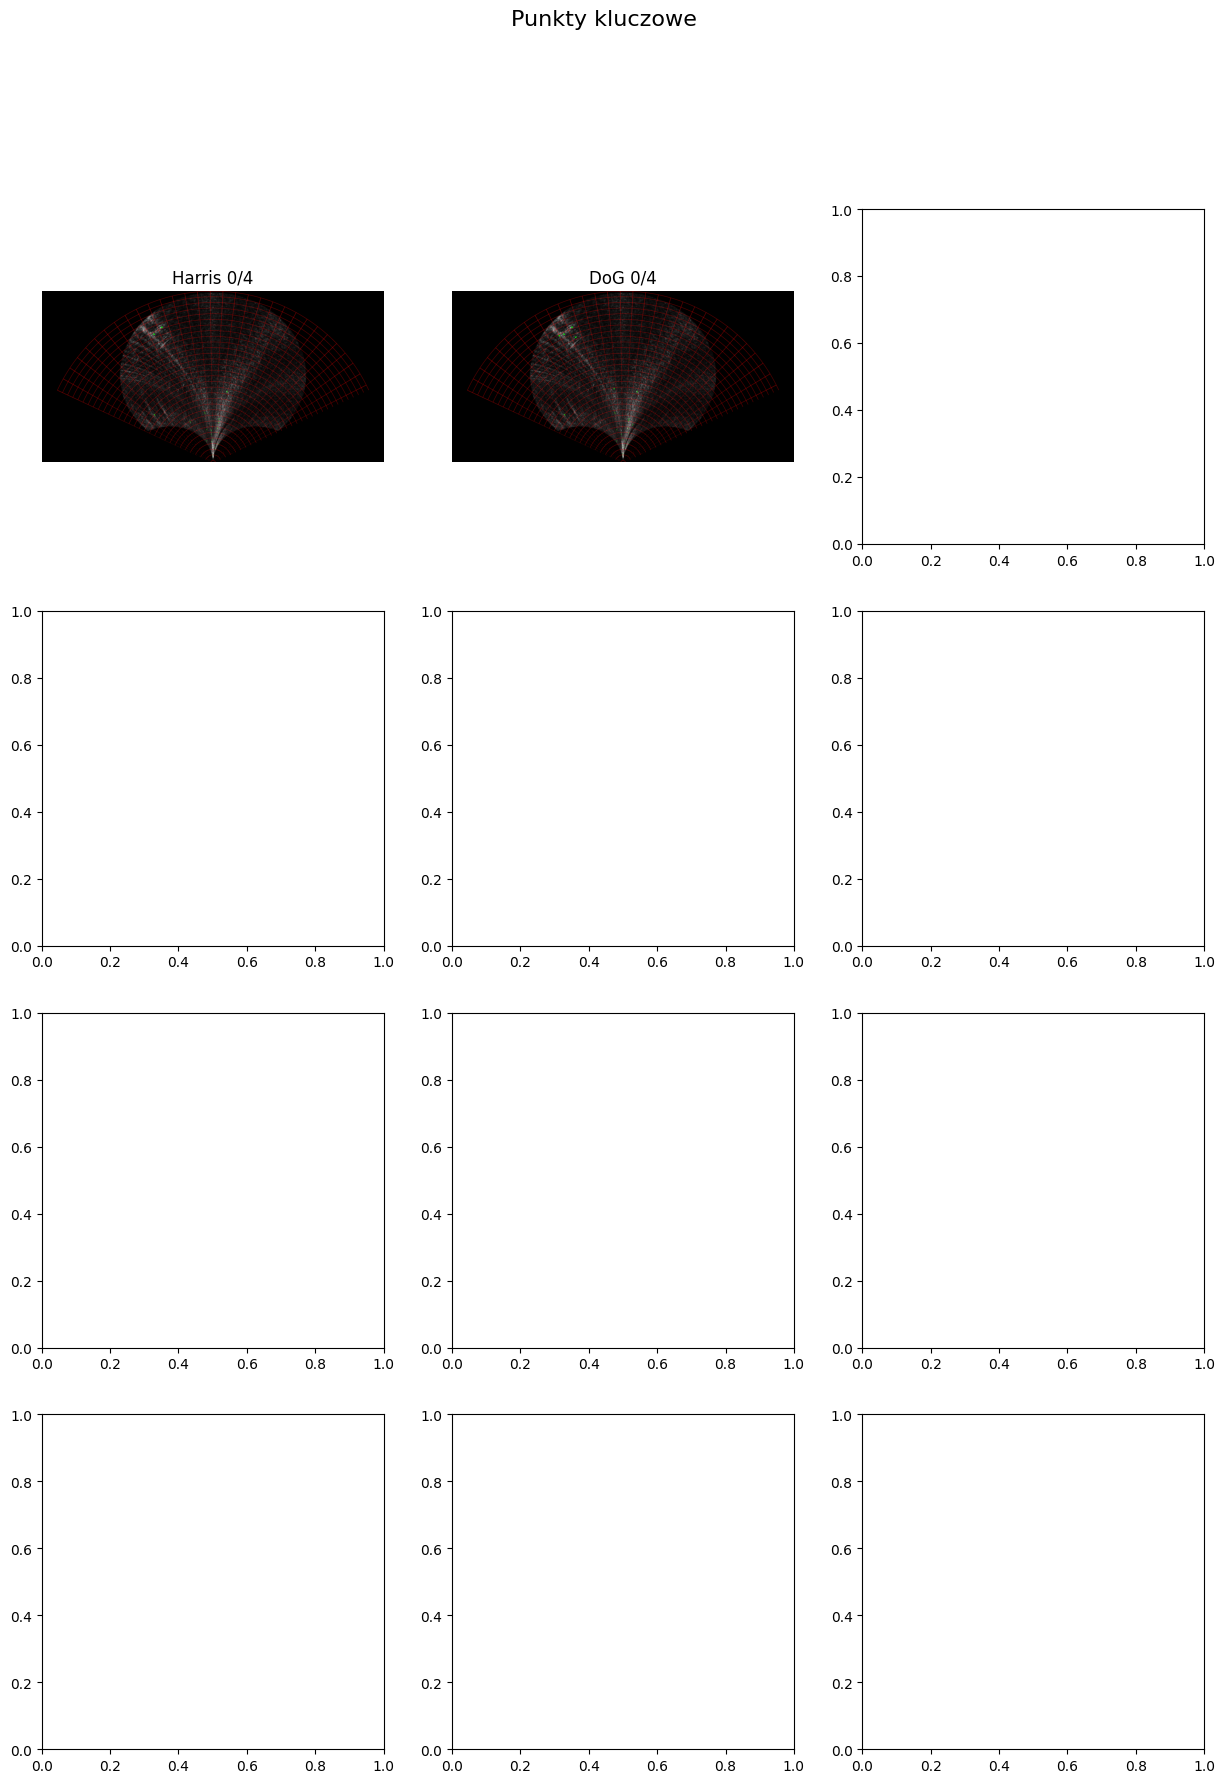

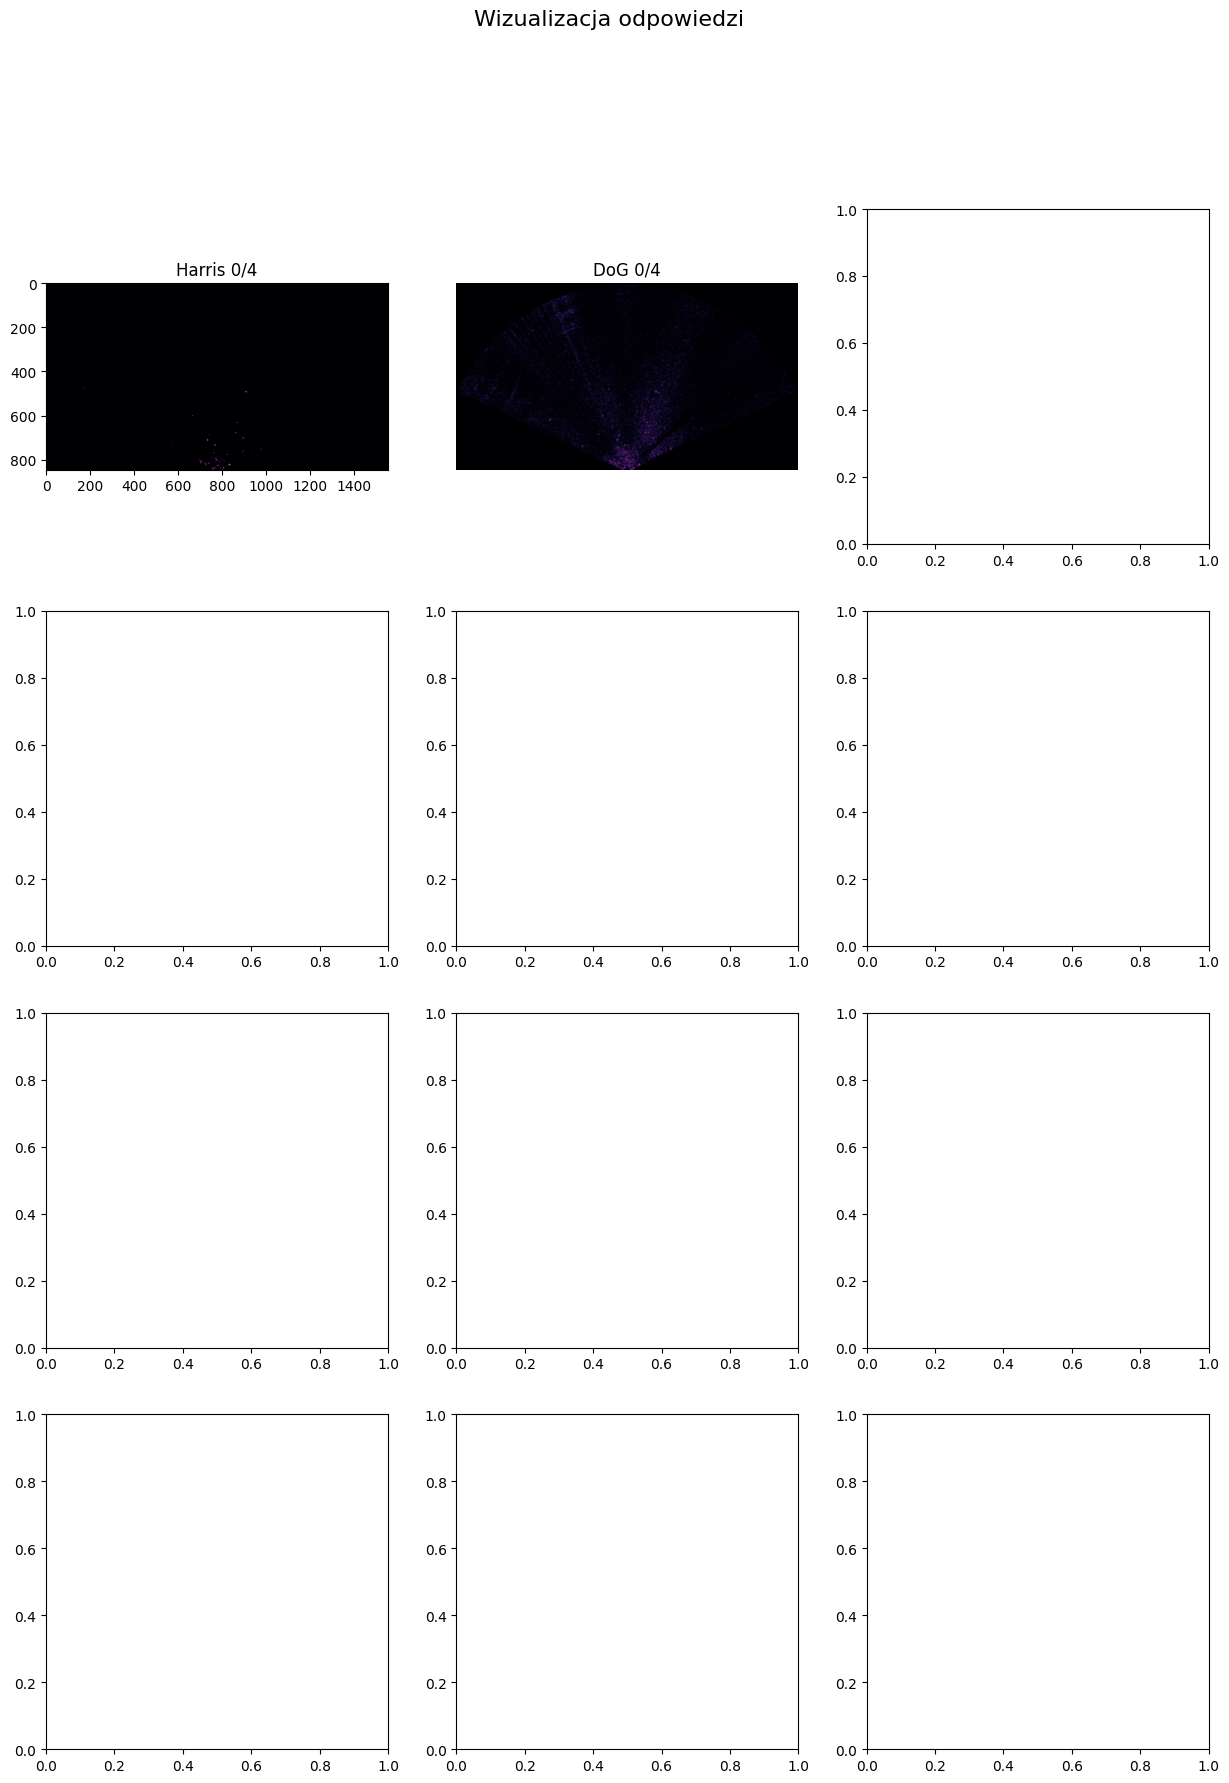

In [15]:
start = 0
frames_num = 4
stride = 5

r_min = sonar_config.range.min
r_max = sonar_config.range.max
theta_max = sonar_config.fov.horizontal

fig1, ax1 = plt.subplots(frames_num, 3, figsize=(15, 5 * frames_num))
fig2, ax2 = plt.subplots(frames_num, 3, figsize=(15, 5 * frames_num))

fig1.suptitle('Punkty kluczowe', fontsize=16)
fig2.suptitle('Wizualizacja odpowiedzi', fontsize=16)


for i in range(frames_num):
    sample_num = start + i * stride
    t, frame, pose, frame_np = data_generator.get_sample(start + i, return_visu=True)

    coords, _, _, _ = patchifier(frame, mode='harris')
    frame_np_visu, harris_response = patchifier.get_visu(frame, coords, mode = 'harris')   
    harris_keypoints = img_polar2cart(frame_np_visu, r_min, r_max, theta_max, out_shape=None, bg=0)

    ax1[i, 0].imshow(harris_keypoints)
    ax1[i, 0].set_title(f'Harris {i}/{frames_num}') 
    ax1[i, 0].axis('off')                         

    ax2[i, 0].imshow(harris_response, cmap = 'magma')
    ax2[i, 0].set_title(f'Harris {i}/{frames_num}')
    ax2[i, 1].axis('off')

    coords, _, _, _ = patchifier(frame, mode='DoG')
    frame_np_visu, DoG_response = patchifier.get_visu(frame, coords, mode='DoG')   
    DoG_keypoints = img_polar2cart(frame_np_visu, r_min, r_max, theta_max, out_shape=None, bg=0)

    ax1[i, 1].imshow(DoG_keypoints)
    ax1[i, 1].set_title(f'DoG {i}/{frames_num}') 
    ax1[i, 1].axis('off')                         

    ax2[i, 1].imshow(DoG_response, cmap = 'magma')
    ax2[i, 1].set_title(f'DoG {i}/{frames_num}')
    ax2[i, 1].axis('off')

    coords, _, _, _ = patchifier(frame, mode='hessian')
    frame_np_visu, hessian_response = patchifier.get_visu(frame, coords, mode='hessian')   
    hessian_keypoints = img_polar2cart(frame_np_visu, r_min, r_max, theta_max, out_shape=None, bg=0)

    ax1[i, 2].imshow(hessian_keypoints)
    ax1[i, 2].set_title(f'Hessian {i}/{frames_num}') 
    ax1[i, 2].axis('off')                         

    ax2[i, 2].imshow(hessian_response, cmap = 'magma')
    ax2[i, 2].set_title(f'Hessian {i}/{frames_num}')
    ax2[i, 2].axis('off')

fig1.tight_layout(rect=[0, 0.03, 1, 0.95])
fig2.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()